# Autoencoder — AE v5

In [19]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Layer
from tensorflow.keras.losses import Loss
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR  = '../../../data/ae_3pct'
MODEL_DIR = '../../../model/ae_3pct'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(tf.config.list_physical_devices())

TensorFlow : 2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Load Data

In [20]:
meta        = joblib.load(f'{MODEL_DIR}/preprocessing_meta.pkl')
SCALED_COLS = meta['scaled_cols']

df_train     = pd.read_csv(f'{DATA_DIR}/pre_train.csv')
df_threshold = pd.read_csv(f'{DATA_DIR}/pre_threshold.csv', parse_dates=['timestamp'])
df_test      = pd.read_csv(f'{DATA_DIR}/pre_test.csv',      parse_dates=['timestamp'])

X_train   = df_train[SCALED_COLS].values.astype(np.float32)
INPUT_DIM = X_train.shape[1]

print(f"X_train   : {X_train.shape}")
print(f"threshold : {df_threshold.shape}")
print(f"test      : {df_test.shape}  (anomali: {int(df_test['label_anomali'].sum())})")
print(f"Input dim : {INPUT_DIM}")
print(f"Features  : {SCALED_COLS}")

X_train   : (178055, 5)
threshold : (45512, 17)
test      : (43925, 17)  (anomali: 1317)
Input dim : 5
Features  : ['nominal_scaled', 'kategori_detail_encoded_scaled', 'hour_sin_scaled', 'hour_cos_scaled', 'nominal_z_user_kat_scaled']


## Custom Components

In [21]:
# ── Custom Loss ───────────────────────────────────────────────────────────────
class WeightedMAELoss(Loss):
    """Per-feature weighted MAE. Heavier penalty on nominal & z-score features."""
    def __init__(self, feature_weights, name='weighted_mae', **kwargs):
        super().__init__(name=name, **kwargs)
        self.feature_weights = list(feature_weights)
        self._w = tf.constant(feature_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred) * self._w)

    def get_config(self):
        return {**super().get_config(), 'feature_weights': self.feature_weights}


# ── Custom Layer ──────────────────────────────────────────────────────────────
class DenoisingNoise(Layer):
    """Injects Gaussian noise during training only — denoising autoencoder."""
    def __init__(self, stddev=0.15, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            return inputs + tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        return inputs

    def get_config(self):
        return {**super().get_config(), 'stddev': self.stddev}


# ── Custom Callback ───────────────────────────────────────────────────────────
class ReconstructionLogger(Callback):
    """Appends p90/p99 MAE on threshold data to logs every log_every epochs."""
    def __init__(self, X_monitor, log_every=5):
        super().__init__()
        self.X_monitor = X_monitor
        self.log_every  = log_every

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_every == 0:
            X_rec = self.model.predict(self.X_monitor, verbose=0)
            mae   = np.abs(self.X_monitor - X_rec).mean(axis=1)
            if logs is not None:
                logs['thr_p90'] = float(np.percentile(mae, 90))
                logs['thr_p99'] = float(np.percentile(mae, 99))


# nominal, kategori_encoded, hour_sin, hour_cos, nominal_z
FEATURE_WEIGHTS = [2.0, 0.5, 1.0, 1.0, 1.5]

print("Custom components ready:")
print(f"  WeightedMAELoss    weights = {FEATURE_WEIGHTS}")
print(f"  DenoisingNoise     stddev  = 0.15")
print(f"  ReconstructionLogger       log_every = 5 epochs")

Custom components ready:
  WeightedMAELoss    weights = [2.0, 0.5, 1.0, 1.0, 1.5]
  DenoisingNoise     stddev  = 0.15
  ReconstructionLogger       log_every = 5 epochs


## Arsitektur

```
Input(5)
→ DenoisingNoise(0.15)
→ Dense(32, relu)  → Dense(16, relu)  → Dense(8, relu)  [bottleneck]
→ Dense(16, relu)  → Dense(32, relu)  → Dense(5, linear)
```

**Loss:** `WeightedMAELoss([2.0, 0.5, 1.0, 1.0, 1.5])` — nominal & z-score upweighted.

In [22]:
def build_autoencoder(input_dim, bottleneck=8):
    inp     = Input(shape=(input_dim,), name='input')
    x       = DenoisingNoise(stddev=0.15, name='denoising')(inp)
    x       = Dense(32, activation='relu', name='enc_1')(x)
    x       = Dense(16, activation='relu', name='enc_2')(x)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)
    x       = Dense(16, activation='relu', name='dec_1')(encoded)
    x       = Dense(32, activation='relu', name='dec_2')(x)
    out     = Dense(input_dim, activation='linear', name='output')(x)
    model   = Model(inputs=inp, outputs=out, name='autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=WeightedMAELoss(FEATURE_WEIGHTS),
    )
    return model

autoencoder = build_autoencoder(INPUT_DIM, bottleneck=8)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoising (DenoisingNoise)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,709 (6.68 KB)

 Trainable params: 1,709 (6.68 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [23]:
X_thr_monitor = df_threshold[SCALED_COLS].values.astype(np.float32)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{MODEL_DIR}/autoencoder.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReconstructionLogger(X_thr_monitor, log_every=5),
]

history = autoencoder.fit(
    X_train, X_train,
    epochs=150,
    batch_size=512,
    validation_split=0.15,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

print(f"Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - loss: 0.3126 - val_loss: 0.1111 - learning_rate: 0.0010
Epoch 2/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.1423 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 3/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 0.1163 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 4/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.1126 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 5/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1101 - val_loss: 0.0469 - learning_rate: 0.0010 - thr_p90: 0.0637 - thr_p99: 0.2130
Epoch 6/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.1087 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 7/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.1076 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 8/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 0.1066 - val_loss: 0.0450 - learning_rate: 0.0010
Epoch 9/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - loss:

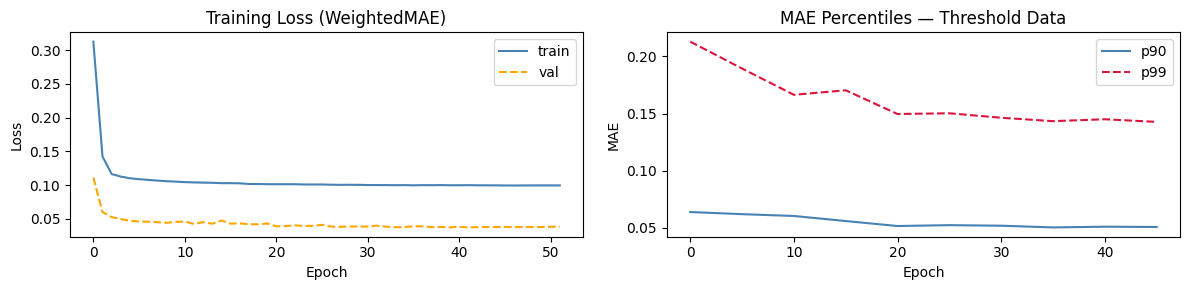

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(history.history['loss'],     label='train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='val',   color='orange', linestyle='--')
axes[0].set(title='Training Loss (WeightedMAE)', xlabel='Epoch', ylabel='Loss')
axes[0].legend()

if 'thr_p90' in history.history:
    axes[1].plot(
        [i * 5 for i in range(len(history.history['thr_p90']))],
        history.history['thr_p90'], label='p90', color='steelblue'
    )
    axes[1].plot(
        [i * 5 for i in range(len(history.history['thr_p99']))],
        history.history['thr_p99'], label='p99', color='crimson', linestyle='--'
    )
    axes[1].set(title='MAE Percentiles — Threshold Data', xlabel='Epoch', ylabel='MAE')
    axes[1].legend()

plt.tight_layout()
plt.show()

## Threshold — F1 Optimized

In [25]:
X_thr     = df_threshold[SCALED_COLS].values.astype(np.float32)
X_thr_rec = autoencoder.predict(X_thr, verbose=0)
df_threshold['mae'] = np.abs(X_thr - X_thr_rec).mean(axis=1)

X_test     = df_test[SCALED_COLS].values.astype(np.float32)
X_test_rec = autoencoder.predict(X_test, verbose=0)
df_test['mae'] = np.abs(X_test - X_test_rec).mean(axis=1)

sweep = []
best_p, best_f1 = 90, 0.0

for p in range(75, 100):
    q = p / 100
    thr_uk = (
        df_threshold.groupby(['id_user', 'kategori_detail'])['mae']
        .quantile(q).rename('threshold').reset_index()
    )
    thr_k = (
        df_threshold.groupby('kategori_detail')['mae']
        .quantile(q).rename('thr_k').reset_index()
    )
    global_thr = float(df_threshold['mae'].quantile(q))

    tmp = (
        df_test[['id_user', 'kategori_detail', 'mae', 'label_anomali']]
        .merge(thr_uk, on=['id_user', 'kategori_detail'], how='left')
        .merge(thr_k,  on='kategori_detail',              how='left')
    )
    tmp['threshold'] = tmp['threshold'].fillna(tmp['thr_k']).fillna(global_thr)

    preds = (tmp['mae'] > tmp['threshold']).astype(int)
    f1    = f1_score(tmp['label_anomali'], preds, zero_division=0)
    sweep.append({'percentile': p, 'global_thr': round(global_thr, 5), 'f1': round(f1, 4)})

    if f1 > best_f1:
        best_f1, best_p = f1, p

sweep_df = pd.DataFrame(sweep)
print(f"Best threshold percentile : p{best_p}  (F1 = {best_f1:.4f})")
print(sweep_df.to_string(index=False))

Best threshold percentile : p97  (F1 = 0.1483)
 percentile  global_thr     f1
         75     0.03719 0.1081
         76     0.03787 0.1093
         77     0.03858 0.1108
         78     0.03931 0.1124
         79     0.03996 0.1137
         80     0.04071 0.1144
         81     0.04145 0.1155
         82     0.04229 0.1176
         83     0.04318 0.1199
         84     0.04406 0.1207
         85     0.04499 0.1233
         86     0.04609 0.1244
         87     0.04705 0.1276
         88     0.04824 0.1294
         89     0.04956 0.1306
         90     0.05109 0.1338
         91     0.05288 0.1372
         92     0.05471 0.1401
         93     0.05695 0.1411
         94     0.06010 0.1430
         95     0.06597 0.1437
         96     0.07388 0.1469
         97     0.08991 0.1483
         98     0.11022 0.1461
         99     0.14404 0.1438


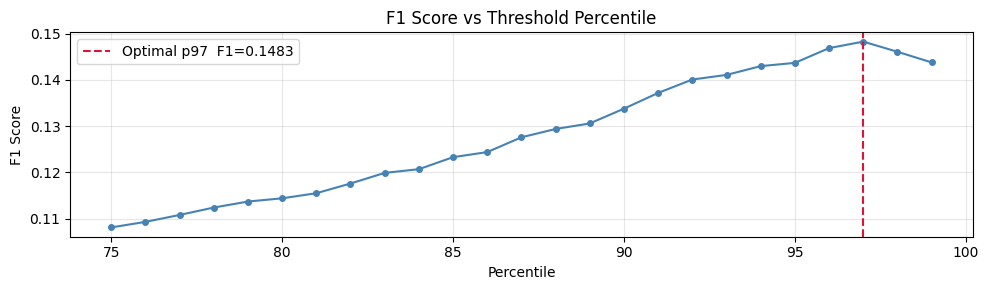

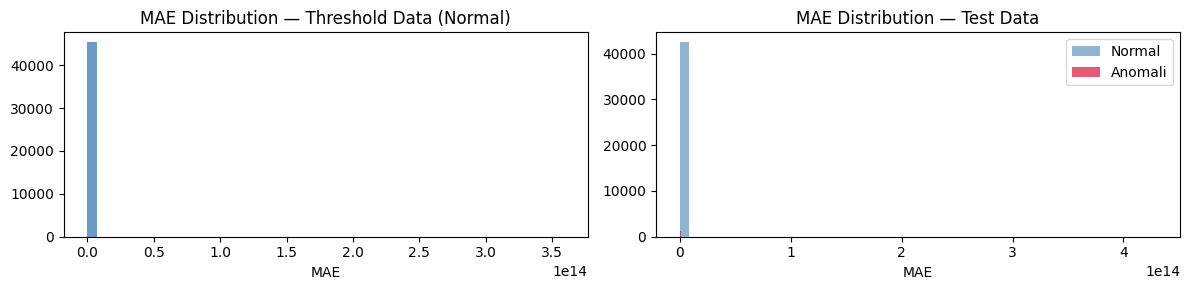

In [26]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sweep_df['percentile'], sweep_df['f1'], marker='o', color='steelblue', markersize=4)
ax.axvline(best_p, color='crimson', linestyle='--', label=f'Optimal p{best_p}  F1={best_f1:.4f}')
ax.set(title='F1 Score vs Threshold Percentile', xlabel='Percentile', ylabel='F1 Score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 3))
axes2[0].hist(df_threshold['mae'], bins=50, color='steelblue', alpha=0.8)
axes2[0].set(title='MAE Distribution — Threshold Data (Normal)', xlabel='MAE')
axes2[1].hist(df_test[df_test['label_anomali']==0]['mae'], bins=50, alpha=0.6, color='steelblue', label='Normal')
axes2[1].hist(df_test[df_test['label_anomali']==1]['mae'], bins=50, alpha=0.7, color='crimson',   label='Anomali')
axes2[1].set(title='MAE Distribution — Test Data', xlabel='MAE')
axes2[1].legend()
plt.tight_layout()
plt.show()

## Evaluasi Test

Threshold : p97 (F1-optimal) — no dual-AND condition
              precision    recall  f1-score   support

      Normal       0.98      0.68      0.80     42608
     Anomali       0.06      0.62      0.10      1317

    accuracy                           0.68     43925
   macro avg       0.52      0.65      0.45     43925
weighted avg       0.95      0.68      0.78     43925



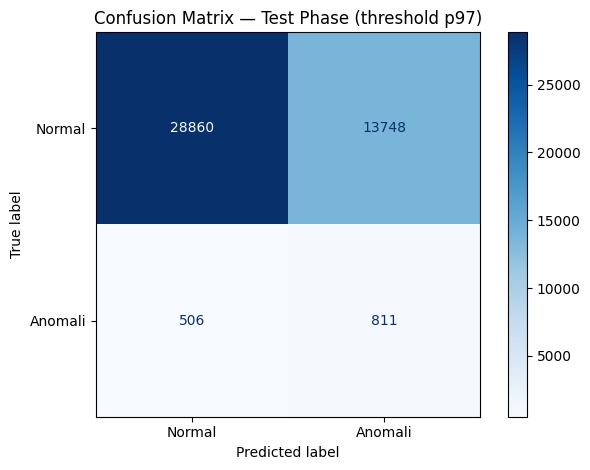

In [ ]:
q_best = best_p / 100

threshold_user_kat = (
    df_threshold.groupby(['id_user', 'kategori_detail'])['mae']
    .quantile(q_best).rename('threshold').reset_index()
)
threshold_kat = (
    df_threshold.groupby('kategori_detail')['mae']
    .quantile(q_best).to_dict()
)
global_threshold = float(df_threshold['mae'].quantile(q_best))

df_eval = (
    df_test
    .merge(threshold_user_kat, on=['id_user', 'kategori_detail'], how='left')
)
df_eval['threshold'] = (
    df_eval['threshold']
    .fillna(df_eval['kategori_detail'].map(threshold_kat))
    .fillna(global_threshold)
)

df_eval['pred_anomali'] = (df_eval['mae'] > df_eval['threshold']).astype(int)

y_true = df_eval['label_anomali'].values.astype(int)
y_pred = df_eval['pred_anomali'].values

print(f"Threshold : p{best_p} (F1-optimal) — no dual-AND condition")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomali']))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — Test Phase (threshold p{best_p})')
plt.tight_layout()
plt.show()

## Simpan

In [28]:
threshold_dict = {
    (row['id_user'], row['kategori_detail']): row['threshold']
    for _, row in threshold_user_kat.iterrows()
}

joblib.dump({
    'threshold_user_kat' : threshold_dict,
    'threshold_kat'      : threshold_kat,
    'global_threshold'   : global_threshold,
    'best_percentile'    : best_p,
    'scaled_cols'        : SCALED_COLS,
    'feature_weights'    : FEATURE_WEIGHTS,
}, f'{MODEL_DIR}/model_meta.pkl')

print(f"autoencoder.keras → {MODEL_DIR}")
print(f"model_meta.pkl    → {MODEL_DIR}")
print(f"\nThreshold percentile : p{best_p}")
print(f"Global threshold     : {global_threshold:.6f}")
print(f"User×kategori pairs  : {len(threshold_dict)}")

autoencoder.keras → ../../../model/ae_3pct
model_meta.pkl    → ../../../model/ae_3pct

Threshold percentile : p97
Global threshold     : 0.089906
User×kategori pairs  : 3892
